AI/ML Internship Assignment
Dataset: House Prices – Advanced Regression Techniques (Kaggle)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("train.csv")
# Display first five rows
print("First Five Rows")
print(df.head())
# Dataset shape
print("\nDataset Shape:", df.shape)
# Column names
print("\nColumn Names")
print(df.columns)
# Dataset information
print("\nDataset Information")
df.info()
# Statistical summary
print("\nSummary Statistics")
print(df.describe())
# Number of rows and columns
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
# Target variable
target = "SalePrice"
print("\nTarget Variable:", target)
# Selected feature
feature = "GrLivArea"
print("Selected Feature:", feature)
# Display selected columns
print("\nSelected Features")
print(df[['GrLivArea', 'SalePrice']].head())

First Five Rows
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2

In [11]:

# Phase 3 : Data Preprocessing

# Select required columns
housing = df[['GrLivArea', 'SalePrice']].copy()
print("First Five Rows")
print(housing.head())

print("Missing Values")
print(housing.isnull().sum())

print("Duplicate Records")
print(housing.duplicated().sum())

# Remove duplicates if any
housing.drop_duplicates(inplace=True)


print("Data Types")
print(housing.dtypes)


print("Dataset Information")
housing.info()


print("Summary Statistics")
print(housing.describe())


print("Final Dataset Shape")
print(housing.shape)

First Five Rows
   GrLivArea  SalePrice
0       1710     208500
1       1262     181500
2       1786     223500
3       1717     140000
4       2198     250000
Missing Values
GrLivArea    0
SalePrice    0
dtype: int64
Duplicate Records
6
Data Types
GrLivArea    int64
SalePrice    int64
dtype: object
Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 1454 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   GrLivArea  1454 non-null   int64
 1   SalePrice  1454 non-null   int64
dtypes: int64(2)
memory usage: 34.1 KB
Summary Statistics
         GrLivArea      SalePrice
count  1454.000000    1454.000000
mean   1516.638239  181159.178817
std     525.788022   79509.859968
min     334.000000   34900.000000
25%    1131.000000  130000.000000
50%    1465.000000  163500.000000
75%    1779.000000  214000.000000
max    5642.000000  755000.000000
Final Dataset Shape
(1454, 2)


Statistical Summary
         GrLivArea      SalePrice
count  1454.000000    1454.000000
mean   1516.638239  181159.178817
std     525.788022   79509.859968
min     334.000000   34900.000000
25%    1131.000000  130000.000000
50%    1465.000000  163500.000000
75%    1779.000000  214000.000000
max    5642.000000  755000.000000


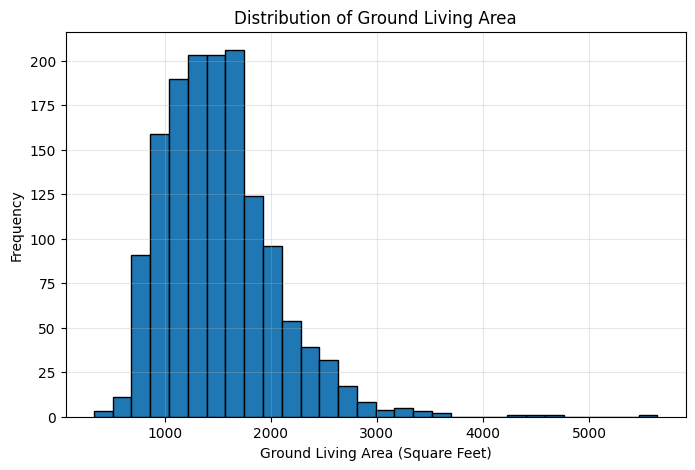

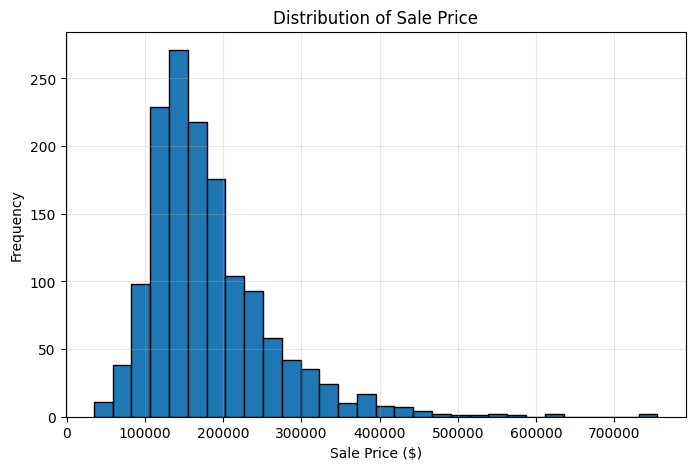

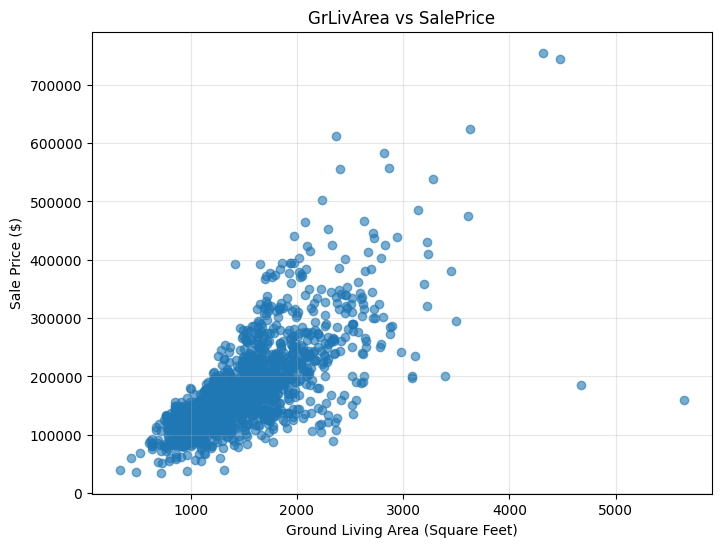


Correlation Coefficient: 0.709

Correlation Matrix
           GrLivArea  SalePrice
GrLivArea   1.000000   0.708635
SalePrice   0.708635   1.000000


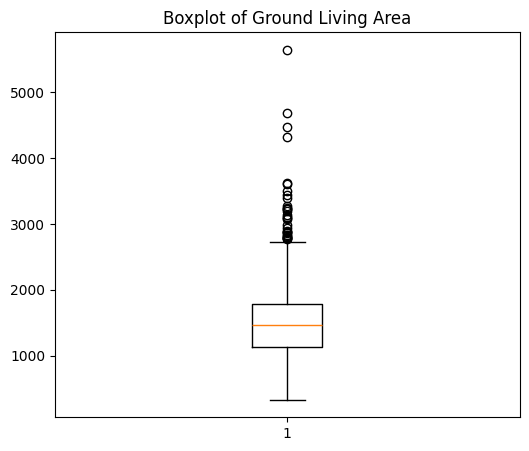

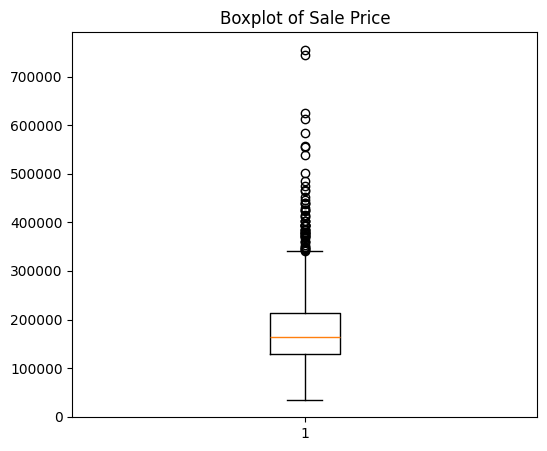


Number of Outliers: 31

First Five Outliers:
     GrLivArea  SalePrice
58        2945     438780
118       3222     320000
185       3608     475000
197       3112     235000
231       2794     403000


In [12]:
import matplotlib.pyplot as plt

# Statistical Summary
print("="*50)
print("Statistical Summary")
print("="*50)
print(housing.describe())

# Histogram - GrLivArea
plt.figure(figsize=(8,5))
plt.hist(housing['GrLivArea'], bins=30, edgecolor='black')
plt.title("Distribution of Ground Living Area")
plt.xlabel("Ground Living Area (Square Feet)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Histogram - SalePrice
plt.figure(figsize=(8,5))
plt.hist(housing['SalePrice'], bins=30, edgecolor='black')
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(housing['GrLivArea'], housing['SalePrice'], alpha=0.6)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Ground Living Area (Square Feet)")
plt.ylabel("Sale Price ($)")
plt.grid(alpha=0.3)
plt.show()

# Correlation
correlation = housing['GrLivArea'].corr(housing['SalePrice'])
print("\nCorrelation Coefficient:", round(correlation,3))

# Correlation Matrix
print("\nCorrelation Matrix")
print(housing.corr())

# Boxplot - GrLivArea
plt.figure(figsize=(6,5))
plt.boxplot(housing['GrLivArea'])
plt.title("Boxplot of Ground Living Area")
plt.show()

# Boxplot - SalePrice
plt.figure(figsize=(6,5))
plt.boxplot(housing['SalePrice'])
plt.title("Boxplot of Sale Price")
plt.show()

# Outlier Detection using IQR
Q1 = housing['GrLivArea'].quantile(0.25)
Q3 = housing['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = housing[
    (housing['GrLivArea'] < lower_bound) |
    (housing['GrLivArea'] > upper_bound)
]

print("\nNumber of Outliers:", len(outliers))
print("\nFirst Five Outliers:")
print(outliers.head())

Regression Equation:
SalePrice = 107.16 × GrLivArea + 18636.04

First 10 Predictions
   Actual Price  Predicted Price
0        208500    201879.848904
1        181500    153872.113727
2        223500    210024.018265
3        140000    202629.969767
4        250000    254173.989008
5        143000    164588.126044
6        307000    200165.286934
7        200000    242600.695706
8        129900    208738.096787
9        118000    134047.490942


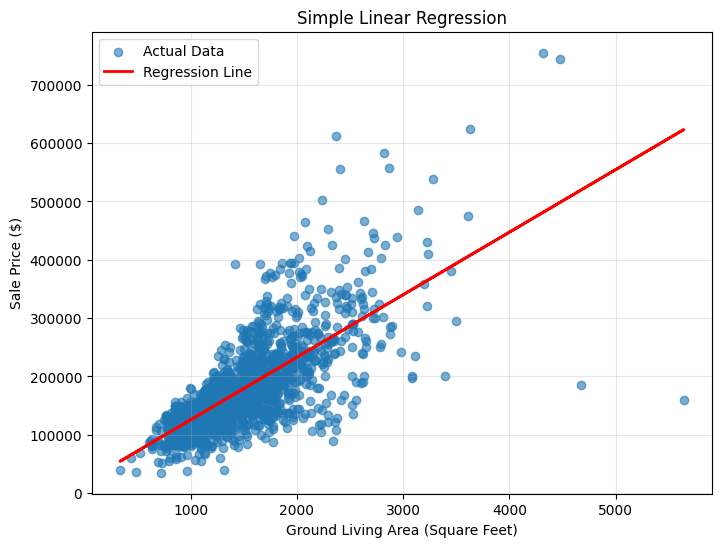

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Independent and Dependent Variables
X = housing['GrLivArea'].values
y = housing['SalePrice'].values

# Calculate means
x_mean = np.mean(X)
y_mean = np.mean(y)

# Calculate slope
numerator = np.sum((X - x_mean) * (y - y_mean))
denominator = np.sum((X - x_mean) ** 2)

m = numerator / denominator

# Calculate intercept
b = y_mean - (m * x_mean)

# Regression Equation
print(f"Regression Equation:")
print(f"SalePrice = {m:.2f} × GrLivArea + {b:.2f}")

# Predictions
y_pred = m * X + b

# Comparison Table
comparison = pd.DataFrame({
    "Actual Price": y,
    "Predicted Price": y_pred
})

print("\nFirst 10 Predictions")
print(comparison.head(10))

# Plot Regression Line
plt.figure(figsize=(8,6))

plt.scatter(X, y, alpha=0.6, label="Actual Data")
plt.plot(X, y_pred, color='red', linewidth=2, label="Regression Line")

plt.title("Simple Linear Regression")
plt.xlabel("Ground Living Area (Square Feet)")
plt.ylabel("Sale Price ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [13]:
# Phase 6: Model Evaluation

import numpy as np

# Mean Absolute Error
mae = np.mean(np.abs(y - y_pred))

# Mean Squared Error
mse = np.mean((y - y_pred) ** 2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
ss_total = np.sum((y - y_mean) ** 2)
ss_residual = np.sum((y - y_pred) ** 2)

r2 = 1 - (ss_residual / ss_total)

# Display Results

print("Model Evaluation Metrics")


print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics
Mean Absolute Error (MAE): 37663.37
Mean Squared Error (MSE): 3145062268.28
Root Mean Squared Error (RMSE): 56080.85
R² Score: 0.5022
